In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import numpy
# create an alias so “numpy._core.numeric” points to the real module
sys.modules['numpy._core.numeric'] = numpy.core.numeric
import pickle 
import ast
from collections.abc import Iterable
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances

#import the modules for analyzing the results of the k-path search
from Path_Analytics import *


Goal: Create a set of analytics functions for the output of identified paths 
-
0) create a binary matrix of rows of paths and columns of drugs 
1) Distribution of drugs in each successful path across all conversions
2) Total number of successful paths for each conversion 
3) Unsupervised clustering for each conversion 
    - redundancy - total paths for each cluster 
    - uniqueness - total number of clusters per conversion 

In [ ]:
#read in the pickle file 
with open('search_results_hpc_k15_steps7.pkl', 'rb') as f:
    df = pickle.load(f)
    
import numpy as np
print(df['covered_threshold'].value_counts())
#filter down to only those that were successful
df = df[df['covered_threshold']==True]
df

False    12415
True      9764
Name: covered_threshold, dtype: int64


,search_id,type_of_search,n_steps,k,starting_cl,target_cl,starting_position,target_position,starting_distance,target_radius,step,path_type,is_best_at_step,is_success,covered_threshold,end_position,path,genes_targeted,cell_path,final_distance
0,0,k_paths,7,15,CVCL_0023,CVCL_0028,"[1.3879085, -0.5934151, -1.3808976, -1.5999688...","[-0.6713518, 0.08039375, 2.5241747, -0.3909294...",7.360779,1.0,3,threshold,True,False,True,"[-1.2986359555357312, 0.1297046237265045, 2.44...","[[('Ipatasertib', 5.0, 'uM')], [('venetoclax',...","[(akt1, akt2, akt3), (bcl2,), (slc46a1, folr1,...","[[CVCL_0023, CVCL_1716], [CVCL_0023, None], [C...",4.328716
1,0,k_paths,7,15,CVCL_0023,CVCL_0028,"[1.3879085, -0.5934151, -1.3808976, -1.5999688...","[-0.6713518, 0.08039375, 2.5241747, -0.3909294...",7.360779,1.0,3,threshold,False,False,True,"[-1.2920285080742355, 0.1718884933373761, 2.29...","[[('Ipatasertib', 5.0, 'uM')], [('venetoclax',...","[(akt1, akt2, akt3), (bcl2,), (adra2b, aoc3, a...","[[CVCL_0023, CVCL_1716], [CVCL_0023, None], [C...",4.355498
2,0,k_paths,7,15,CVCL_0023,CVCL_0028,"[1.3879085, -0.5934151, -1.3808976, -1.5999688...","[-0.6713518, 0.08039375, 2.5241747, -0.3909294...",7.360779,1.0,4,threshold,True,False,True,"[-1.327162096781245, 0.13712862705015838, 2.28...","[[('Ipatasertib', 5.0, 'uM')], [('venetoclax',...","[(akt1, akt2, akt3), (bcl2,), (slc46a1, folr1,...","[[CVCL_0023, CVCL_1716], [CVCL_0023, None], [C...",4.063258
3,0,k_paths,7,15,CVCL_0023,CVCL_0028,"[1.3879085, -0.5934151, -1.3808976, -1.5999688...","[-0.6713518, 0.08039375, 2.5241747, -0.3909294...",7.360779,1.0,4,threshold,False,False,True,"[-1.1742238157800833, 0.08693414607161175, 2.2...","[[('Ipatasertib', 5.0, 'uM')], [('venetoclax',...","[(akt1, akt2, akt3), (bcl2,), (slc46a1, folr1,...","[[CVCL_0023, CVCL_1716], [CVCL_0023, None], [C...",4.063779
4,0,k_paths,7,15,CVCL_0023,CVCL_0028,"[1.3879085, -0.5934151, -1.3808976, -1.5999688...","[-0.6713518, 0.08039375, 2.5241747, -0.3909294...",7.360779,1.0,4,threshold,False,False,True,"[-1.1759434656747996, 0.08676039236786068, 2.2...","[[('Ipatasertib', 5.0, 'uM')], [('venetoclax',...","[(akt1, akt2, akt3), (bcl2,), (ar,), (slc46a1,...","[[CVCL_0023, CVCL_1716], [CVCL_0023, None], [C...",4.068549
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22165,2254,k_paths,7,15,CVCL_C466,CVCL_1724,"[3.62401, 2.5263758, -0.24609329, 0.8415634, -...","[-2.5716736, -0.5042123, -0.5165198, 0.0117397...",9.303772,1.0,6,threshold,False,False,True,"[-0.8370369114798892, 0.11313813777151195, 0.5...","[[('olaparib', 5.0, 'uM')], [('venetoclax', 5....","[(parp3, parp2, parp1), (bcl2,), (gnrhr,), (cn...","[[CVCL_C466, CVCL_1715], [CVCL_C466, None], [C...",5.475071
22166,2254,k_paths,7,15,CVCL_C466,CVCL_1724,"[3.62401, 2.5263758, -0.24609329, 0.8415634, -...","[-2.5716736, -0.5042123, -0.5165198, 0.0117397...",9.303772,1.0,6,threshold,False,False,True,"[-0.9866993342858119, -0.1466261743885398, 0.6...","[[('olaparib', 5.0, 'uM')], [('venetoclax', 5....","[(parp3, parp2, parp1), (bcl2,), (cnr1,), (gnr...","[[CVCL_C466, CVCL_1715], [CVCL_C466, None], [C...",5.478708
22167,2254,k_paths,7,15,CVCL_C466,CVCL_1724,"[3.62401, 2.5263758, -0.24609329, 0.8415634, -...","[-2.5716736, -0.5042123, -0.5165198, 0.0117397...",9.303772,1.0,6,threshold,False,False,True,"[-0.9857640180516496, -0.14656402764708854, 0....","[[('olaparib', 5.0, 'uM')], [('venetoclax', 5....","[(parp3, parp2, parp1), (bcl2,), (gnrhr,), (cn...","[[CVCL_C466, CVCL_1715], [CVCL_C466, None], [C...",5.479077
22168,2254,k_paths,7,15,CVCL_C466,CVCL_1724,"[3.62401, 2.5263758, -0.24609329, 0.8415634, -...","[-2.5716736, -0.5042123, -0.5165198, 0.0117397...",9.303772,1.0,6,threshold,False,False,True,"[-0.9764658697154807, -0.14605317349122934, 0....","[[('olaparib', 5.0, 'uM')], [('venetoclax', 5....","[(parp3, parp2, parp1), (bcl2,), (cnr1,), (gnr...","[[CVCL_C466, CVCL_1715], [CVCL_C466, None], [C...",5.482198


In [24]:
#create the binary drug matrix for each conversion 
drug_matrix = build_conversion_drug_matrix(df)
drug_matrix

,conversion,(R)-Verapamil (hydrochloride),(S)-Crizotinib,AZD-8055,Abemaciclib,Acetazolamide,Adenosine,Afatinib,Aliskiren,Allopurinol,...,Vemurafenib,Verapamil,Vinblastine (sulfate),Vismodegib,Volasertib,Zileuton,crizotinib,olaparib,venetoclax,vincristine
0,CVCL_0023:CVCL_0028,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,CVCL_0023:CVCL_0028,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,CVCL_0023:CVCL_0028,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
3,CVCL_0023:CVCL_0028,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,CVCL_0023:CVCL_0028,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22165,CVCL_C466:CVCL_1724,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
22166,CVCL_C466:CVCL_1724,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
22167,CVCL_C466:CVCL_1724,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
22168,CVCL_C466:CVCL_1724,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0


Need to add:
- frequency distribution of drug in all paths 
- identify the drug with the highest frequency in all conversion and output that frequency (maybe 1st and 2nd highest frequency drug)

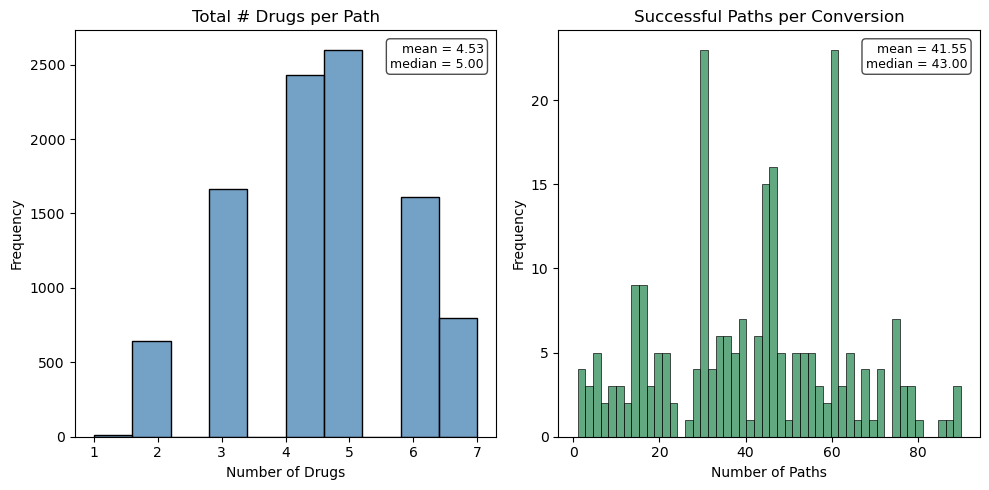

(<Figure size 1000x500 with 2 Axes>,
 array([<Axes: title={'center': 'Total # Drugs per Path'}, xlabel='Number of Drugs', ylabel='Frequency'>,
        <Axes: title={'center': 'Successful Paths per Conversion'}, xlabel='Number of Paths', ylabel='Frequency'>],
       dtype=object))

In [25]:
#plot initial QC for the drug matrix - global metrics
plot_path_and_conversion_histograms(drug_matrix, 
                                    figsize=(10,5), 
                                    bins_drugs=10, 
                                    bins_conv=50)

#implement nearest neighbor and TSNE and UMAP

Jaccard Distance Threshold with Heirarchical clustering
-
option: Try different similarity parameters to ensure robust clustering

Meaning:
- 0.1 - 0.3 = Only paths with almost identical drug sets merge.
- 0.4 - 0.6 = Paths must share a fair proportion of drugs; moderate strictness
- 0.7 - 0.9 = Paths that share just a handful of drugs can end up together; coarse granularity
- 0.9 - 1.0 = Nearly everything collapses into one cluster (unless totally disjoint)

In [31]:
#now we can unsupervised cluster the conversions based on the drug matrix 
summary, detailed = cluster_all_conversions(
    drug_matrix,
    metric="jaccard",
    distance_threshold=0.5,
)
summary

,conversion,n_clusters,mean_cluster_size,median_cluster_size
0,CVCL_0023:CVCL_0028,2,23.500000,23.5
1,CVCL_0023:CVCL_0179,3,14.333333,20.0
2,CVCL_0023:CVCL_0292,18,3.333333,1.0
3,CVCL_0023:CVCL_0480,1,1.000000,1.0
4,CVCL_0023:CVCL_1547,4,8.000000,6.5
...,...,...,...,...
230,CVCL_C466:CVCL_1577,10,6.000000,1.0
231,CVCL_C466:CVCL_1635,1,21.000000,21.0
232,CVCL_C466:CVCL_1716,19,2.368421,1.0
233,CVCL_C466:CVCL_1717,20,3.000000,1.0


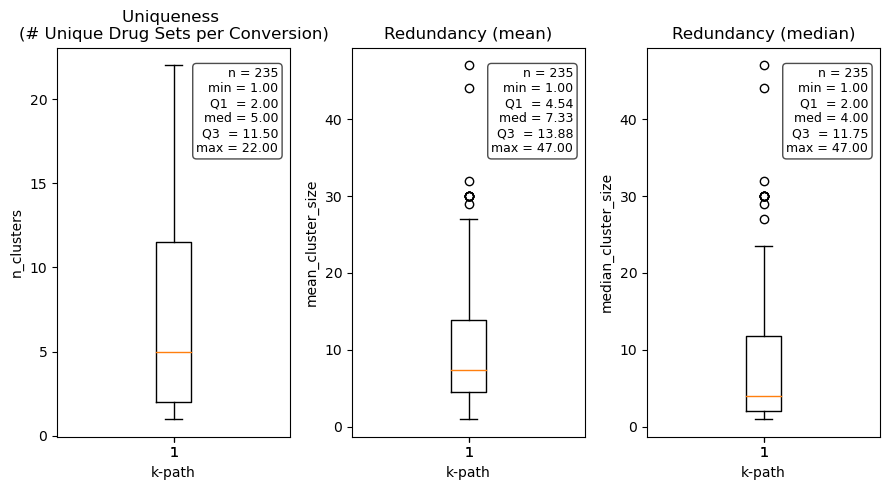

(<Figure size 900x500 with 3 Axes>,
 array([<Axes: title={'center': 'Uniqueness \n(# Unique Drug Sets per Conversion)'}, xlabel='k-path', ylabel='n_clusters'>,
        <Axes: title={'center': 'Redundancy (mean)'}, xlabel='k-path', ylabel='mean_cluster_size'>,
        <Axes: title={'center': 'Redundancy (median)'}, xlabel='k-path', ylabel='median_cluster_size'>],
       dtype=object))

In [32]:
#plot the summary of the clustering results
plot_cluster_summary(
    summary,
    x_label="k-path",
    figsize=(9, 5),
    show=True
)